# Project summary — Kaggle Playground Series S6E8

This portfolio-facing notebook condenses nine controlled experiments into the evidence behind the final model. It reads saved reports only—no model is trained here.

> **Final champion: 0.964777 matched OOF ROC AUC · 0.96621 public Kaggle ROC AUC**  
> **Model: 40% LightGBM / 60% XGBoost**, with the original predictors plus two compact screen-time contrasts.

OOF validation drove every modeling decision. Public leaderboard scores are shown separately and were recorded after the corresponding experiment.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")
ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
REPORTS = ROOT / "reports"

required = [
    "model_comparison.csv", "feature_ablation.csv", "feature_engineering.csv",
    "feature_robustness.csv", "tuned_blend_results.csv",
    "lightgbm_convergence.csv", "xgboost_convergence.csv",
    "convergence_blend_results.csv", "convergence_analysis.json",
    "repeated_cv_summary.csv", "repeated_cv_comparisons.csv",
    "feature_discovery_screen.csv", "feature_discovery_confirmation.csv",
]
missing = [name for name in required if not (REPORTS / name).exists()]
assert not missing, f"Missing saved reports: {missing}"
print("Loaded saved presentation reports")

Loaded saved presentation reports


## Problem, data, and validation

The task is binary probability prediction for `addicted_label`, evaluated by ROC AUC. Training contains 691,369 rows; test contains 296,302. There are 12 predictors—9 numeric and 3 low-cardinality categorical—and every predictor has some missing values. The unique `id` column is excluded.

Experiments E1–E7 reuse the identical five-fold `StratifiedKFold(shuffle=True, random_state=42)` split. Complete OOF probabilities provide the primary score, and paired bootstrap comparisons assess small proposed gains. E8 holds configurations fixed across five additional split seeds; E9 freezes one development-screen feature before applying the same confirmation seeds. Public leaderboard scores never select features, parameters, schedules, or ensemble weights.

## Experiment progression

The sequence deliberately changes one major dimension at a time: baseline → model family → blend → features → tuning → convergence.

,experiment,decision,oof_auc,public_auc
0,E1,Logistic baseline,0.913785,—
1,E2,LightGBM control,0.960604,0.96197
2,E3,50/50 LGB/XGB,0.961044,0.96236
3,E4,+ screen/work-study contrast,0.961326,0.96252
4,E5,Tuned 50/50 blend,0.963943,0.96527
5,E6,40/60 convergence blend,0.964289,0.96567
6,E7,Diversity test; retain E6,0.964289,—
7,E8,Repeated-CV confirmation; retain E6,0.964289,—
8,E9,Targeted feature; local promotion,0.964777,0.96621


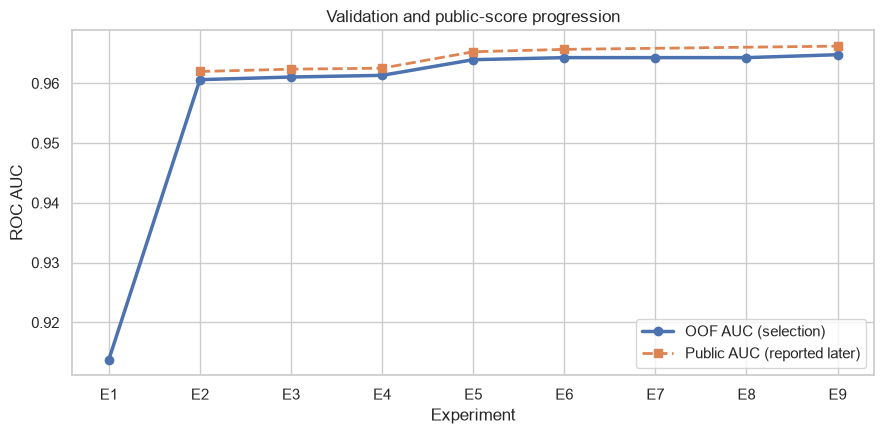

In [2]:
progression = pd.DataFrame({
    "experiment": ["E1", "E2", "E3", "E4", "E5", "E6", "E7", "E8", "E9"],
    "decision": [
        "Logistic baseline", "LightGBM control", "50/50 LGB/XGB",
        "+ screen/work-study contrast", "Tuned 50/50 blend", "40/60 convergence blend",
        "Diversity test; retain E6", "Repeated-CV confirmation; retain E6",
        "Targeted feature; local promotion",
    ],
    "oof_auc": [0.9137848668, 0.9606037579, 0.9610442846, 0.9613259226, 0.9639433758, 0.9642892514, 0.9642892514, 0.9642892514, 0.9647766677],
    "public_auc": [np.nan, 0.96197, 0.96236, 0.96252, 0.96527, 0.96567, np.nan, np.nan, 0.96621],
})
display(progression.style.format({"oof_auc": "{:.6f}", "public_auc": "{:.5f}"}, na_rep="—"))

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(progression["experiment"], progression["oof_auc"], marker="o", linewidth=2.5, label="OOF AUC (selection)")
public = progression.dropna(subset=["public_auc"])
ax.plot(public["experiment"], public["public_auc"], marker="s", linestyle="--", linewidth=2, label="Public AUC (reported later)")
ax.set(title="Validation and public-score progression", xlabel="Experiment", ylabel="ROC AUC")
ax.legend(frameon=True)
plt.tight_layout()
plt.show()

The biggest gain comes from moving beyond a linear decision surface in E2. Later increments are smaller, so promotion standards become stricter: transfer across models, a broad parameter or weight region, and paired uncertainty all matter.

## Baseline and model-family comparison

The constant-probability baseline establishes the ROC AUC floor at 0.500000; logistic regression reaches 0.913785. Gradient-boosted trees then produce the decisive improvement. LightGBM and XGBoost are effectively tied, which is more useful as an ensemble opportunity than as evidence that one implementation is universally superior.

,model,oof_auc,oof_log_loss,std_fold_auc,total_fit_seconds,total_predict_seconds
15,LightGBM,0.960604,0.232012,0.000769,12.6,1.44
10,XGBoost,0.960596,0.231060,0.000651,11.9,0.38
5,HistGradientBoosting,0.957157,0.242273,0.000748,12.6,0.99
20,CatBoost,0.953305,0.251253,0.000689,103.0,0.21
0,LogisticRegression,0.913785,0.338347,0.000861,4.9,0.38


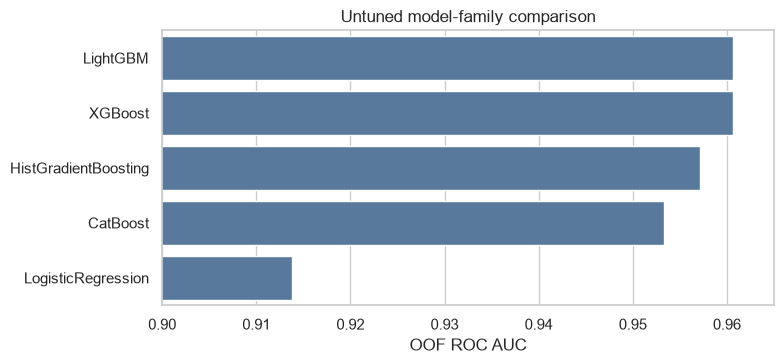

In [3]:
comparison = pd.read_csv(REPORTS / "model_comparison.csv")
models = (comparison.drop_duplicates("model")
          .loc[:, ["model", "oof_auc", "oof_log_loss", "std_fold_auc", "total_fit_seconds", "total_predict_seconds"]]
          .sort_values("oof_auc", ascending=False))
display(models.style.format({
    "oof_auc": "{:.6f}", "oof_log_loss": "{:.6f}", "std_fold_auc": "{:.6f}",
    "total_fit_seconds": "{:.1f}", "total_predict_seconds": "{:.2f}",
}))

fig, ax = plt.subplots(figsize=(8, 3.8))
sns.barplot(data=models, x="oof_auc", y="model", color="#4C78A8", ax=ax)
ax.set_xlim(0.90, 0.965)
ax.set(title="Untuned model-family comparison", xlabel="OOF ROC AUC", ylabel="")
plt.tight_layout()
plt.show()

## Feature findings

Ablation measures marginal predictive contribution, not causality. Screen-time and engagement-frequency variables are the largest contributors to LightGBM. Explicit missingness indicators did not improve native tree handling.

Of eight conservative candidate features, only the difference between `daily_screen_time_hours` and `work_study_hours` transferred to both LightGBM and XGBoost. The historical code name is `leisure_screen_proxy`, but “screen/work-study contrast” avoids asserting an unsupported semantic decomposition.

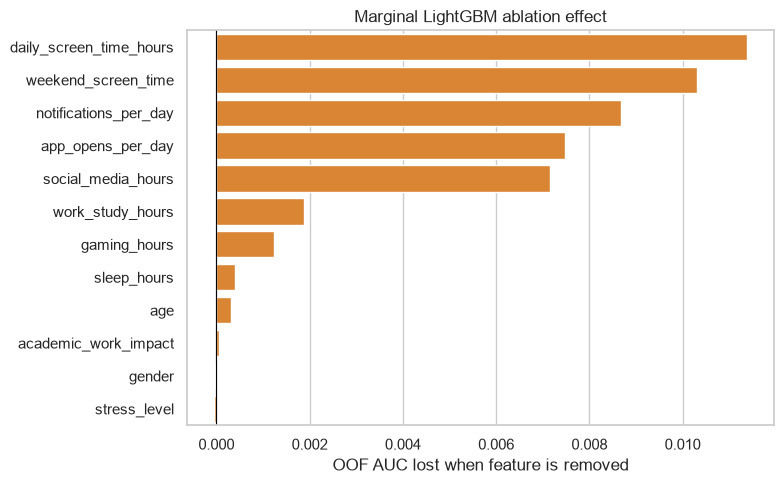

,model,oof_auc,delta_vs_current_champion
0,LightGBM,0.960797,-0.000247
1,XGBoost,0.960905,-0.000139
2,Blend50_50,0.961326,+0.000282


In [4]:
ablations = pd.read_csv(REPORTS / "feature_ablation.csv")
ablation_plot = (ablations[ablations["experiment"].str.startswith("drop_")]
                 .assign(feature=lambda d: d["experiment"].str.removeprefix("drop_"),
                         auc_lost_when_removed=lambda d: -d["delta_vs_raw_lightgbm"])
                 .sort_values("auc_lost_when_removed", ascending=False))

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=ablation_plot, x="auc_lost_when_removed", y="feature", color="#F58518", ax=ax)
ax.axvline(0, color="black", linewidth=0.8)
ax.set(title="Marginal LightGBM ablation effect", xlabel="OOF AUC lost when feature is removed", ylabel="")
plt.tight_layout()
plt.show()

robustness = pd.read_csv(REPORTS / "feature_robustness.csv")
display(robustness[["model", "oof_auc", "delta_vs_current_champion"]].style.format({
    "oof_auc": "{:.6f}", "delta_vs_current_champion": "{:+.6f}",
}))

The engineered blend reaches 0.961326 OOF AUC, +0.000282 over E3. Most ratios, all-feature missing indicators, and multi-feature combinations are retained as negative results rather than hidden after selection.

## Tuning, convergence, and ensemble rationale

Conservative tuning supported a broad pattern: both boosters benefited from more capacity and slower learning. E6 then held tree structure fixed and varied only learning rate and round allowance. The 0.02 schedules were strongest for both families; early stopping found 3,808 median rounds for LightGBM and 4,720 for XGBoost, although one XGBoost fold remained partially cap-limited.

Simple blending captures complementary ranking information. A broad 30–50% LightGBM region is nearly tied, so the 40/60 result is treated as a robust plateau—not a precisely optimized weight.

,family,learning_rate,max_estimators,oof_auc,median_best_iteration,folds_without_full_stopping_window
0,LightGBM,0.05,2500,0.963321,1641,0
1,LightGBM,0.03,3500,0.963379,2730,0
2,LightGBM,0.02,5000,0.963424,3808,0
3,XGBoost,0.05,2500,0.963930,1822,0
4,XGBoost,0.03,3500,0.963955,2888,0
5,XGBoost,0.02,5000,0.963991,4720,1


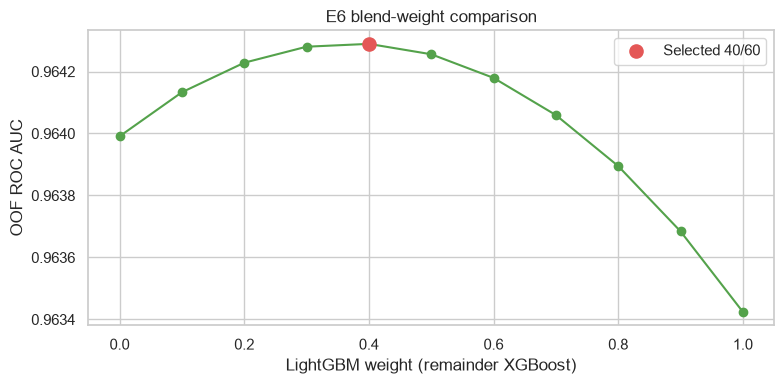

In [5]:
lgb_conv = pd.read_csv(REPORTS / "lightgbm_convergence.csv")
xgb_conv = pd.read_csv(REPORTS / "xgboost_convergence.csv")
conv = pd.concat([lgb_conv, xgb_conv], ignore_index=True)
display(conv[["family", "learning_rate", "max_estimators", "oof_auc", "median_best_iteration", "folds_without_full_stopping_window"]]
        .style.format({"learning_rate": "{:.2f}", "oof_auc": "{:.6f}", "median_best_iteration": "{:.0f}"}))

blend = pd.read_csv(REPORTS / "convergence_blend_results.csv")
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(blend["lightgbm_weight"], blend["oof_auc"], marker="o", color="#54A24B")
best = blend.loc[blend["oof_auc"].idxmax()]
ax.scatter([best["lightgbm_weight"]], [best["oof_auc"]], s=90, color="#E45756", zorder=3, label="Selected 40/60")
ax.set(title="E6 blend-weight comparison", xlabel="LightGBM weight (remainder XGBoost)", ylabel="OOF ROC AUC")
ax.legend()
plt.tight_layout()
plt.show()

## Current local model

| Component | Final specification | OOF AUC |
|---|---|---:|
| LightGBM | learning rate 0.02, 3,808 rounds, 63 leaves | 0.963424 |
| XGBoost | learning rate 0.02, 4,720 rounds, depth 7 | 0.963991 |
| **E6 blend** | **40% LightGBM / 60% XGBoost** | **0.964289** |

The blend improves E5 by +0.000346 OOF AUC. A paired 500-resample bootstrap gives a 95% interval of [0.000308, 0.000387], positive in every resample. Its separately observed public Kaggle AUC is **0.96567**.

E8 kept all configurations fixed and repeated the E4→E5→E6 comparison across five additional split seeds. E6 beat E5 on all five by a mean +0.000327 AUC (seed-bootstrap 95% interval [+0.000320, +0.000335]); E5 also beat E4 on all five. The 40/60 weight beat the neighboring 30/70 and 50/50 blends every time, but by only about 0.00002 AUC—confirmation of a flat, robust blend region rather than evidence for precise weight optimization.

E9 predeclared ten targeted behavioral representations and promoted only `unallocated_screen_contrast = daily_screen_time_hours - social_media_hours - gaming_hours - work_study_hours`. With fixed E6 rounds, both components improve and the matched seed-42 blend reaches **0.964777**, +0.000485 over its control. The exact feature wins on all five additional seeds by a mean +0.000525 (seed-bootstrap interval [+0.000508, +0.000539]). After this local decision, E9 scored **0.96621 public AUC**, +0.00054 over E6. The close agreement is encouraging external consistency, while the single public holdout is not treated as statistical confirmation.

## Key lessons and unsuccessful approaches

- Stable folds and complete OOF predictions made small later-stage gains comparable.
- Near-tied models can be more valuable as ensemble partners than as winner/loser candidates.
- Feature engineering required cross-model transfer; most plausible ratios did not help.
- Native missing-value handling outperformed adding indicator columns.
- Neighboring parameter support mattered more than an isolated numerical winner.
- Fine-grained blend-weight optimization was unnecessary because the useful region was flat.
- CatBoost, HistGradientBoosting, shallow XGBoost, several regularization variants, and combined weak features did not replace the final approach.
- E7 confirmed that lower correlation is not enough: ExtraTrees added substantial disagreement but degraded every tested blend, while 5% depth-7 CatBoost gained only 0.000002 AUC with a bootstrap interval crossing zero.
- E8 showed why final-model confirmation matters: fixed E4, E5, and E6 decisions retained their ordering on every additional split seed without turning those seeds into another tuning surface.
- E9 showed that a hypothesis-driven residual contrast can transfer, while nine other plausible shares, deviations, balances, and interactions did not clear a fixed cross-model gate.

The final sequence is deliberately conservative: E7 rejects diversity without conditional accuracy, E8 confirms E6 across alternative splits, and E9 promotes one hypothesis-driven feature only after cross-model and cross-seed transfer. E9 is the final champion; its public result is reported as a later holdout observation, not a model-selection input.